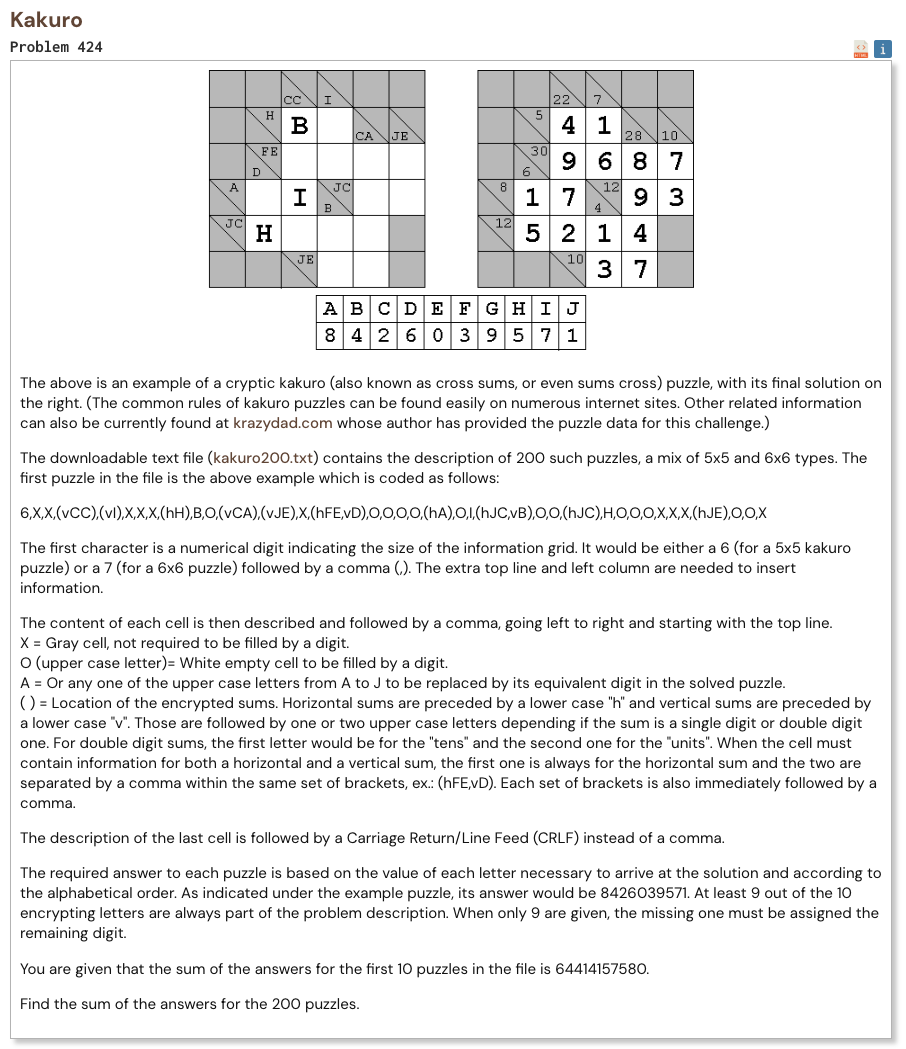

## Initial approach

-   treat every letter from A to J as an unknown digit
-   treat every empty Kakuro cell as another unknown digit
-   use `itertools` to generate valid groups of different digits for each possible Kakuro sum
-   read every horizontal and vertical clue and connect it to its white cells
-   remove digit choices that cannot satisfy their Kakuro clue
-   also make sure all letters from A to J represent different digits
-   use backtracking when the remaining rules are not enough to determine the next digit
-   solve all 200 puzzles and add the decoded ten digit answers

In [1]:
%%time

from itertools import permutations
from collections import defaultdict
from pathlib import Path

DIGITS = set(range(10))
CELL_DIGITS = set(range(1, 10))

valid_runs = {}

for length in range(1, 7):
    groups = defaultdict(list)

    for values in permutations(range(1, 10), length):
        groups[sum(values)].append(values)

    valid_runs[length] = groups


def split_line(line):
    first, text = line.strip().split(",", 1)
    size = int(first)

    cells = []
    current = []
    depth = 0

    for ch in text:
        if ch == "(":
            depth += 1
        elif ch == ")":
            depth -= 1

        if ch == "," and depth == 0:
            cells.append("".join(current))
            current = []
        else:
            current.append(ch)

    if current:
        cells.append("".join(current))

    return size, cells


def is_white(token):
    return token == "O" or (
        len(token) == 1 and "A" <= token <= "J"
    )


def clue_parts(token):
    if not token.startswith("("):
        return []

    result = []

    for part in token[1:-1].split(","):
        direction = part[0]
        letters = tuple(ord(ch) - ord("A") for ch in part[1:])
        result.append((direction, letters))

    return result


def build_problem(line):
    size, tokens = split_line(line)

    domains = [set(DIGITS) for _ in range(10)]
    cell_var = {}
    next_var = 10

    for r in range(size):
        for c in range(size):
            token = tokens[r * size + c]

            if token == "O":
                cell_var[(r, c)] = next_var
                domains.append(set(CELL_DIGITS))
                next_var += 1

            elif len(token) == 1 and "A" <= token <= "J":
                var = ord(token) - ord("A")
                cell_var[(r, c)] = var
                domains[var].discard(0)

    runs = []

    for r in range(size):
        for c in range(size):
            token = tokens[r * size + c]

            for direction, letters in clue_parts(token):
                if len(letters) == 2:
                    domains[letters[0]].discard(0)

                cells = []

                if direction == "h":
                    cc = c + 1

                    while cc < size and is_white(tokens[r * size + cc]):
                        cells.append(cell_var[(r, cc)])
                        cc += 1

                else:
                    rr = r + 1

                    while rr < size and is_white(tokens[rr * size + c]):
                        cells.append(cell_var[(rr, c)])
                        rr += 1

                runs.append((tuple(cells), letters))

    return domains, runs


def enforce_letters(domains):
    changed = False

    singles = {}

    for i in range(10):
        if not domains[i]:
            return False, changed

        if len(domains[i]) == 1:
            value = next(iter(domains[i]))

            if value in singles:
                return False, changed

            singles[value] = i

    for value, owner in singles.items():
        for i in range(10):
            if i != owner and value in domains[i]:
                domains[i].remove(value)
                changed = True

                if not domains[i]:
                    return False, changed

    for value in range(10):
        owners = [
            i
            for i in range(10)
            if value in domains[i]
        ]

        if not owners:
            return False, changed

        if len(owners) == 1 and len(domains[owners[0]]) > 1:
            domains[owners[0]] = {value}
            changed = True

    return True, changed


def clue_values(letters, domains):
    if len(letters) == 1:
        var = letters[0]

        for value in domains[var]:
            yield value, {var: value}

    else:
        a, b = letters

        for x in domains[a]:
            for y in domains[b]:
                if a == b and x != y:
                    continue

                if a != b and x == y:
                    continue

                yield 10 * x + y, {a: x, b: y}


def filter_run(domains, cells, letters):
    support = {}

    for var in set(cells) | set(letters):
        support[var] = set()

    found = False
    length = len(cells)

    for target, clue_assignment in clue_values(letters, domains):
        if target not in valid_runs[length]:
            continue

        for values in valid_runs[length][target]:
            assignment = dict(clue_assignment)
            good = True

            for var, value in zip(cells, values):
                if value not in domains[var]:
                    good = False
                    break

                if var in assignment and assignment[var] != value:
                    good = False
                    break

                assignment[var] = value

            if not good:
                continue

            used = {}
            valid_letters = True

            for var, value in assignment.items():
                if var < 10:
                    if value in used and used[value] != var:
                        valid_letters = False
                        break

                    used[value] = var

            if not valid_letters:
                continue

            found = True

            for var in support:
                support[var].add(assignment[var])

    if not found:
        return False, False

    changed = False

    for var, allowed in support.items():
        new_domain = domains[var] & allowed

        if not new_domain:
            return False, changed

        if new_domain != domains[var]:
            domains[var] = new_domain
            changed = True

    return True, changed


def propagate(domains, runs):
    while True:
        changed = False

        ok, letter_changed = enforce_letters(domains)

        if not ok:
            return False

        changed |= letter_changed

        for cells, letters in runs:
            ok, run_changed = filter_run(
                domains,
                cells,
                letters
            )

            if not ok:
                return False

            changed |= run_changed

        if not changed:
            return True


def solve(domains, runs):
    domains = [set(values) for values in domains]

    if not propagate(domains, runs):
        return None

    candidates = [
        i
        for i, values in enumerate(domains)
        if len(values) > 1
    ]

    if not candidates:
        return domains

    var = min(
        candidates,
        key=lambda i: (
            len(domains[i]),
            0 if i < 10 else 1
        )
    )

    for value in sorted(domains[var]):
        next_domains = [
            set(values)
            for values in domains
        ]

        next_domains[var] = {value}

        result = solve(next_domains, runs)

        if result is not None:
            return result

    return None


def decode(domains):
    answer = 0

    for i in range(10):
        answer = answer * 10 + next(iter(domains[i]))

    return answer


def solve_puzzle(line):
    domains, runs = build_problem(line)
    solution = solve(domains, runs)

    if solution is None:
        raise ValueError("Puzzle could not be solved")

    return decode(solution)


lines = [
    line
    for line in Path("0424_kakuro200.txt").read_text().splitlines()
    if line.strip()
]

answers = [solve_puzzle(line) for line in lines]

assert answers[0] == 8426039571
assert sum(answers[:10]) == 64414157580

result = sum(answers)

print("Result:", result)

Result: 1059760019628
CPU times: user 2.83 s, sys: 13.1 ms, total: 2.84 s
Wall time: 2.86 s
